# 04 — Global Multi-Ward Temporal RL Training
Trains PPO, A2C, and DQN agents on a randomized multi-ward, multi-scenario environment.
Collects temporal ward traces for the area model.
**Run 01 and 02 first.**

In [1]:
import sys, os
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np

# Change this line so it automatically looks at the parent directory!
PROJECT_ROOT = Path(os.getcwd()).resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: D:\Bunker\BaseCamp\Hierarchical-multi-agent-RL-for-Urban-Traffic


In [2]:
# Load all 16 Wards from Registry
registry_path = PROJECT_ROOT / 'configs' / 'hierarchy' / 'ward_registry.json'
with registry_path.open('r') as f:
    registry = json.load(f)
    WARD_IDS = list(registry.get('wards', {}).keys())

# SCENARIOS = [
#     'normal', 
#     'peak_congestion', 
#     'traffic_surge', 
#     'blocked_road', 
#     'ambulance_emergency', 
#     'vip_convoy', 
#     'chaos_mode',
#     'breakdown',
#     'asymmetric_overload',
#     'low_baseline'
# ]
SCENARIOS = [
    'normal', 
    'peak_congestion', 
    'traffic_surge', 
    'blocked_road', 
    'ambulance_emergency', 
]

# ALGORITHMS = ['ppo', 'a2c', 'dqn']
ALGORITHMS = ['ppo']
EPISODES = 150
GUI = False

print(f'Configured {len(WARD_IDS)} Wards and {len(SCENARIOS)} Scenarios for Global Training.')

Configured 16 Wards and 5 Scenarios for Global Training.


In [5]:
from src.rl.train import train_global_agent

all_rewards = {}

for algo in ALGORITHMS:
    print(f'\n======================================`==')
    print(f'🚀 Starting Global Training: {algo.upper()}')
    print(f'========================================')
    
    result = train_global_agent(
        ward_ids=WARD_IDS,
        scenario_ids=SCENARIOS,
        project_root=PROJECT_ROOT,
        algorithm=algo,
        episodes=EPISODES,
        gui=GUI,
        collect_gnn_data=(algo == 'ppo'), # Only collect GNN data once to save space
    )
    
    all_rewards[algo] = result['episode_rewards']
    
    print(f'\n✅ {algo.upper()} Finished in {result["training_time"]/60:.1f} mins')
    print(f'Model saved at: {result["model_path"]}')


======================================`==
🚀 Starting Global Training: PPO


RL Agent Training:   1%|          | 1/150 [00:38<1:34:38, 38.11s/it, ep_reward=-5135.8, avg_10_ep=-5135.8]

KeyboardInterrupt: 

Performance plot saved to D:\Bunker\BaseCamp\Hierarchical-multi-agent-RL-for-Urban-Traffic\results\training\wards\image\global_training_performance.png


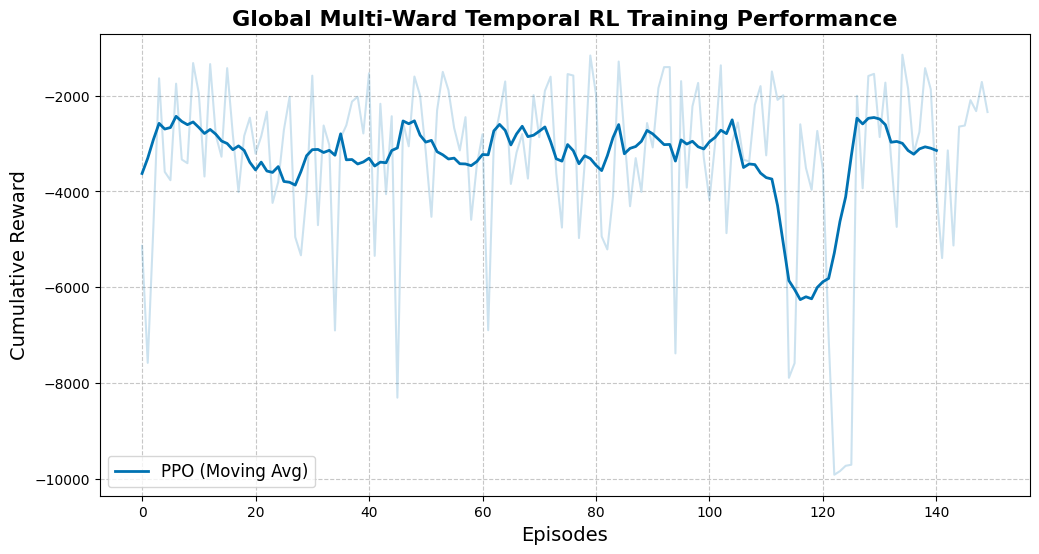

In [4]:
# Plotting Performance
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='valid')
    return y_smooth

plt.figure(figsize=(12, 6))
colors = {'ppo': '#0072B2', 'a2c': '#D55E00', 'dqn': '#009E73'}

for algo, rewards in all_rewards.items():
    if len(rewards) > 10:
        smoothed = smooth(rewards, 10)
        plt.plot(smoothed, label=f'{algo.upper()} (Moving Avg)', color=colors[algo], linewidth=2)
        plt.plot(rewards, alpha=0.2, color=colors[algo])

plt.title('Global Multi-Ward Temporal RL Training Performance', fontsize=16, fontweight='bold')
plt.xlabel('Episodes', fontsize=14)
plt.ylabel('Cumulative Reward', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Save Plot
save_dir = PROJECT_ROOT / 'results' / 'training' / 'wards' / 'image'
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'global_training_performance.png'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f'Performance plot saved to {save_path}')

plt.show()
